In [ ]:
import matplotlib
import pandas as pd
import chess
from chess.engine import EngineTerminatedError
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from utils import get_db_connection, get_stockfish_engine
import statsmodels.formula.api as smf
import seaborn as sns
from joblib import Parallel, delayed
import os
from voc_analysis import compute_voc


In [ ]:
# Pick N complete games (metadata filters), then every half-move for those gids.
GAMES_CACHE = "full_games_moves.parquet"
N_GAMES = 2000

need_reload = not os.path.exists(GAMES_CACHE)
if os.path.exists(GAMES_CACHE):
    sample_games = pd.read_parquet(GAMES_CACHE)
    need_reload = need_reload or ("clock_increment" not in sample_games.columns)
if need_reload:
    # utils.get_db_connection defaults (20GB, many threads) can OOM small hosts / Jupyter.
    conn = get_db_connection(threads=4, memory_limit="6GB")
    start_date = "2022-01-01"
    end_date = "2022-12-31"
    db_path = '/scratch/gpfs/GRIFFITHS/chess-db/lichess.db'
    try:
        conn.execute(f"ATTACH '{db_path}' AS core (READ_ONLY)")
    except Exception as e:
        print(f"Warning attaching database: {e}")

    sample_games = conn.sql(f"""
        WITH picked AS (
            SELECT g.gid
            FROM core.games g
            WHERE g.utc_datetime BETWEEN '{start_date}' AND '{end_date}'
            AND g.initial_clock >= 300
            AND g.white_elo >= 2000
            AND g.black_elo >= 2000
            ORDER BY g.gid
            LIMIT {N_GAMES}
        )
        SELECT m.gid, m.board_position, m.move_time, m.move_ply, m.player_white,
            g.white_elo, g.black_elo, g.initial_clock, g.clock_increment
        FROM core.moves m
        JOIN core.games g ON m.gid = g.gid
        INNER JOIN picked p ON m.gid = p.gid
        ORDER BY m.gid, m.move_ply
    """).df()
    conn.close()
    sample_games.to_parquet(GAMES_CACHE)

print(f"{sample_games['gid'].nunique()} games, {len(sample_games)} plys")

1999 games, 148344 plys


In [3]:
# time_left: seconds on the mover's clock *before* this half-move (Fischer increment).
# After each of your moves you gain clock_increment seconds, so:
#   time_left = initial_clock - sum(previous move_times) + n_prior_moves * clock_increment
# Ignoring increment makes cumulative move_time exceed initial_clock in long games → bogus negatives.
# clip move_time at 0 for cumulatives only (a handful of negative values in DB are bad rows).
sample_games = sample_games.sort_values(["gid", "move_ply"], kind="mergesort").reset_index(drop=True)
mt = sample_games["move_time"].fillna(0).clip(lower=0)

cum = sample_games.assign(_mt=mt).groupby(["gid", "player_white"], sort=False)["_mt"].cumsum()
spent_prior = cum - mt
n_prior = sample_games.groupby(["gid", "player_white"], sort=False).cumcount()
inc = sample_games["clock_increment"]
sample_games["time_left"] = (sample_games["initial_clock"] - spent_prior + n_prior * inc).clip(lower=0)

# After you play: lose move time, then increment is added (standard digital clock).
sample_games["time_left_after"] = (sample_games["time_left"] - mt + inc).clip(lower=0)

In [4]:
sample_games.time_left.describe()

count      148344.0
mean     300.017419
std      207.535568
min             0.0
25%           168.0
50%           276.0
75%           411.0
max          3622.0
Name: time_left, dtype: Float64

(array([2.5362e+04, 3.4283e+04, 4.7321e+04, 1.1950e+04, 2.5774e+04,
        1.5570e+03, 3.4600e+02, 6.9600e+02, 1.4900e+02, 1.7000e+02,
        1.2000e+02, 1.5300e+02, 1.4700e+02, 7.2000e+01, 1.4200e+02,
        1.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00, 1.9000e+01,
        1.6000e+01, 7.0000e+00, 7.0000e+00, 7.0000e+00, 6.0000e+00,
        2.0000e+00, 6.0000e+00, 3.0000e+00, 1.0000e+01, 1.5000e+01]),
 array([   0.        ,  120.73333333,  241.46666667,  362.2       ,
         482.93333333,  603.66666667,  724.4       ,  845.13333333,
         965.86666667, 1086.6       , 1207.33333333, 1328.06666667,
        1448.8       , 1569.53333333, 1690.26666667, 1811.        ,
        1931.73333333, 2052.46666667, 2173.2       , 2293.93333333,
        2414.66666667, 2535.4       , 2656.13333333, 2776.86666667,
        2897.6       , 3018.33333333, 3139.06666667, 3259.8       ,
        3380.53333333, 3501.26666667, 3622.        ]),
 <BarContainer object of 30 artists>)

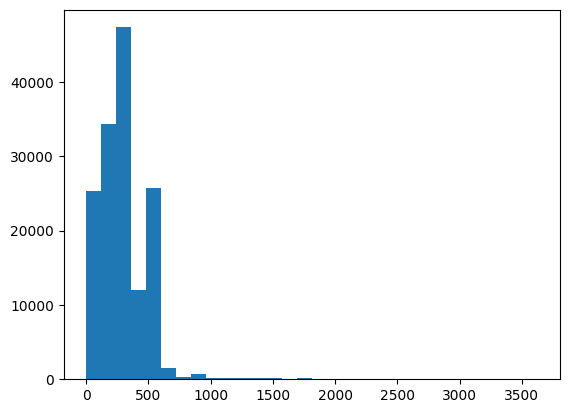

In [5]:
plt.hist(sample_games.time_left, bins=30)

(array([3.0000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.3900e+02, 1.5600e+02, 5.5200e+02,
        1.0350e+03, 2.3440e+03, 4.4210e+03, 6.5950e+03, 1.3528e+04,
        3.8556e+04, 5.4059e+04, 2.5889e+04, 9.3900e+02, 1.0100e+02]),
 array([-11.51292546, -10.85600189, -10.19907832,  -9.54215475,
         -8.88523118,  -8.22830761,  -7.57138404,  -6.91446047,
         -6.2575369 ,  -5.60061333,  -4.94368976,  -4.28676619,
         -3.62984262,  -2.97291905,  -2.31599548,  -1.65907191,
         -1.00214834,  -0.34522477,   0.3116988 ,   0.96862237,
          1.62554594,   2.28246951,   2.93939308,   3.59631665,
          4.25324022,   4.91016379,   5.56708736,   6.22401093,
          6.8809345 ,   7.53785807,   8.19478164]),
 <BarContainer object of 30 artists>)

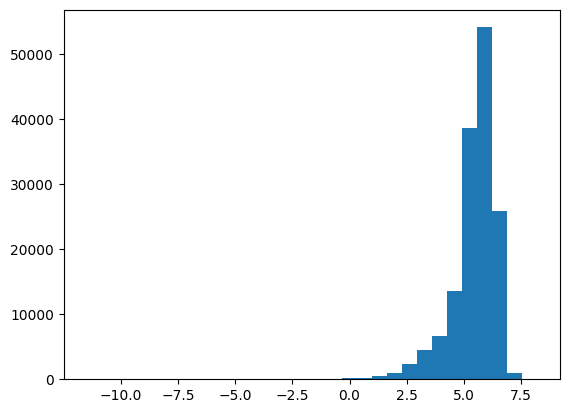

In [6]:
plt.hist(np.log(sample_games.time_left + 1e-5), bins=30)

In [7]:
import statsmodels.formula.api as smf
import numpy as np

EPS = 1e-5  # Small constant to avoid log(0)

# Drop NA values to ensure regression works cleanly
reg_df = sample_games.dropna(subset=["time_left", "move_time"]).copy()
reg_df["log_move_time"] = np.log(reg_df["move_time"] + EPS)
reg_df["log_time_left"] = np.log(reg_df["time_left"] + EPS)

# Fit linear regression: log(move_time) ~ log(time_left)
model = smf.ols("log_move_time ~ log_time_left", data=reg_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_move_time   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3909.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:36:49   Log-Likelihood:            -3.5460e+05
No. Observations:              144340   AIC:                         7.092e+05
Df Residuals:                  144338   BIC:                         7.092e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.7190      0.042    -40.932

/home/hl4291/chess_analysis/.venv/lib/python3.12/site-packages/pandas/core/arrays/masked.py:691: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


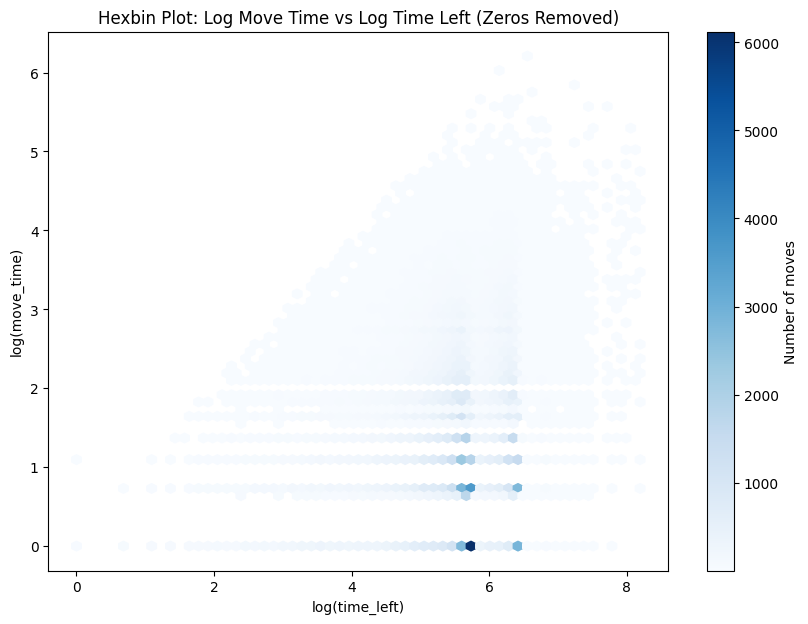

: 

In [ ]:
# Filter out moves where move_time or time_left is 0 to avoid log(EPS) artifacts
reg_df_filtered = reg_df[(reg_df["move_time"] > 0) & (reg_df["time_left"] > 0)]

plt.figure(figsize=(10, 7))
hb = plt.hexbin(
    reg_df_filtered["log_time_left"], 
    reg_df_filtered["log_move_time"], 
    gridsize=60, 
    cmap='YlGnBu', 
    mincnt=1
)
plt.colorbar(hb, label='Number of moves')
plt.xlabel("log(time_left)")
plt.ylabel("log(move_time)")
plt.title("Hexbin Plot: Log Move Time vs Log Time Left (Zeros Removed)")
plt.show()
